# Tiny GPT Trading Signal for Samsung Electronics

이 노트북은 `notebook_05.py`와 `notebook_06.py` 중 **`notebook_06.py`의 Tiny GPT 구조가 더 적절하다**는 판단에 따라 작성되었습니다. `notebook_05.py`는 single-head masked self-attention을 설명하는 데 적합하지만, 실제 가격 시계열의 여러 상태를 읽어 **BUY/HOLD/SELL**을 분류하려면 multi-head attention, feedforward network, residual connection, layer normalization, block stacking을 포함하는 `notebook_06.py`의 구조가 더 확장성이 좋습니다.[^model_choice]

실제 트레이더에서는 먼저 기존 CSV를 준비하고, `export_history.py`를 이용해 최신 일봉 데이터를 CSV에 반영한 뒤, 이 노트북 또는 `tiny_GPT_trading_signal.py`가 갱신된 CSV의 마지막 행을 기준으로 최신 trading signal을 생성합니다.[^refresh_flow]

> **목표**는 삼성전자 일봉 CSV의 OHLCV 정보를 시장 상태 토큰으로 바꾼 다음, Tiny GPT가 최근 `block_size` 거래일의 상태 시퀀스를 읽고 향후 `horizon` 거래일 수익률 기반의 `BUY`, `HOLD`, `SELL` 신호를 예측하도록 만드는 것입니다.

[^model_choice]: `notebook_05.py`의 single-head attention은 GPT의 핵심 원리를 이해하기에 좋지만, 시장 데이터에서는 추세, 모멘텀, 거래량, 변동성 등 여러 신호가 동시에 작동하므로 여러 attention head와 stacked block을 갖는 `notebook_06.py`가 더 자연스럽습니다.
[^refresh_flow]: 여기서 `export_history.py`의 역할은 “모델 학습”이 아니라 “입력 CSV 최신화”입니다. 신호 생성 스크립트는 파일 경로만 받으면 되므로, 자동매매 루프에서는 `export_history.py` 실행 후 같은 CSV 경로를 `--csv`로 넘기는 방식이 가장 단순합니다.

## 1. 전체 파이프라인

아래 표는 자동매매 로직에서 각 파일이 담당하는 역할을 정리한 것입니다.

| 단계 | 담당 파일 | 역할 |
|---:|---|---|
| 1 | `export_history.py` | 기존 CSV에 최신 삼성전자 일봉 데이터를 반영합니다. |
| 2 | `tiny_GPT_trading_signal.py` 또는 본 노트북 | 갱신된 CSV를 읽고 시장 상태 토큰, 학습 라벨, Tiny GPT 예측을 생성합니다. |
| 3 | `latest_trading_signal.json` | 트레이더가 읽을 최신 신호(`BUY`, `HOLD`, `SELL`)와 확률을 저장합니다. |
| 4 | `trader.py` | 기존의 `current_price ± 2000` 중심 로직 대신 신호 기반으로 주문 여부를 결정합니다. |

이 노트북은 연구·검증용이고, 운영에서는 같은 로직을 담은 `tiny_GPT_trading_signal.py`를 커맨드라인에서 실행하는 편이 더 적합합니다.[^notebook_vs_script]

[^notebook_vs_script]: 노트북은 설명과 실험 재현에 좋고, `.py` 스크립트는 자동매매 루프나 배치 실행에 좋습니다. 따라서 두 파일은 같은 설계를 공유하되 사용 목적이 다릅니다.

In [ ]:
# 표준 라이브러리
from __future__ import annotations

import argparse
import copy
import json
import math
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

# 데이터 처리
import numpy as np
import pandas as pd

# PyTorch: notebook_06.py의 Tiny GPT 구조를 거의 그대로 활용합니다.
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# 노트북 출력 가독성 설정
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## 2. 설정값과 라벨 정의

`BUY`, `HOLD`, `SELL`은 향후 `horizon` 거래일 뒤의 수익률을 기준으로 정의합니다. 예를 들어 기본값에서는 5거래일 뒤 수익률이 2% 이상이면 `BUY`, -2% 이하이면 `SELL`, 그 사이면 `HOLD`입니다.[^label_definition]

[^label_definition]: 이 라벨은 “정답”이라기보다 지도학습을 위한 operational definition입니다. 실제 운용에서는 수수료, 세금, 슬리피지, 주문 체결 가능성, 포지션 크기 제한 등을 반영하여 threshold를 조정해야 합니다.

In [ ]:
SIGNAL_TO_ID = {"SELL": 0, "HOLD": 1, "BUY": 2}
ID_TO_SIGNAL = {v: k for k, v in SIGNAL_TO_ID.items()}


@dataclass
class ModelConfig:
    """Tiny GPT 모델 구조 설정.

    검증용 smoke test에서는 작은 모델이 편하지만, `epochs=2`와 작은 모델은
    예측 확률이 1/3 근처에 머무는 underfitting을 만들기 쉽습니다. 따라서
    기본값은 notebook_06.py의 Tiny GPT 구조를 유지하면서도 조금 더 학습 가능한
    `emb_dim=96`, `num_layers=3`으로 조정합니다.
    """

    block_size: int = 64      # 최근 며칠의 시장 상태를 볼 것인지
    emb_dim: int = 96         # 토큰 임베딩 차원
    num_heads: int = 4        # multi-head attention head 수
    num_layers: int = 3       # Transformer block 수
    dropout: float = 0.15


@dataclass
class TrainingConfig:
    """학습 및 라벨 생성 설정.

    기본 epoch를 충분히 늘리고, validation balanced accuracy 기준의 best checkpoint와
    early stopping을 함께 사용합니다. 빠른 실행 확인만 필요하면 아래 실행 셀에서
    `epochs`를 낮추면 됩니다.
    """

    horizon: int = 5
    buy_threshold: float = 0.02
    sell_threshold: float = -0.02
    val_ratio: float = 0.2
    batch_size: int = 128
    epochs: int = 80
    learning_rate: float = 5e-4
    weight_decay: float = 1e-2
    min_confidence: float = 0.45
    early_stop_patience: int = 12
    min_epochs: int = 12
    min_delta: float = 1e-4
    max_grad_norm: float = 1.0
    seed: int = 42


## 3. Dataset: 문자 토큰에서 시장 상태 토큰으로

`notebook_06.py`의 원래 Dataset은 Shakespeare 텍스트에서 다음 문자를 맞히는 구조입니다. 여기서는 같은 “토큰 시퀀스” 개념을 유지하되, 문자 대신 **일별 시장 상태 토큰**을 사용합니다.[^token_shift]

[^token_shift]: GPT 구조 자체는 입력 토큰이 문자, 단어, 코드, 시장 상태 중 무엇인지를 알지 못합니다. 중요한 것은 이산 토큰의 순서와 그 토큰들 사이의 조건부 관계입니다.

In [ ]:
class TradingSignalDataset(Dataset):
    """최근 block_size일의 시장 상태 토큰으로 미래 수익률 기반 신호를 예측하는 Dataset."""

    def __init__(self, token_ids: np.ndarray, labels: np.ndarray, sample_indices: Iterable[int], block_size: int):
        self.token_ids = torch.tensor(token_ids, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.sample_indices = list(sample_indices)
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.sample_indices)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        # end_idx는 예측 기준일입니다.
        # 입력 x는 기준일을 포함한 최근 block_size일의 market_state_token입니다.
        end_idx = self.sample_indices[idx]
        start_idx = end_idx - self.block_size + 1
        x = self.token_ids[start_idx : end_idx + 1]
        y = self.labels[end_idx]
        return x, y

## 4. Tiny GPT 모델

아래 코드는 `notebook_06.py`의 `Head`, `MultiHeadAttention`, `FeedForward`, `Block`, `TinyGPT` 구조를 거래 신호 분류 문제에 맞게 바꾼 것입니다. 핵심 차이는 마지막 layer가 vocabulary 전체의 다음 토큰을 예측하는 대신, 마지막 시점의 hidden state로부터 **3개 클래스 logits**를 출력한다는 점입니다.[^causal_mask]

[^causal_mask]: causal mask는 각 날짜가 자기보다 미래 날짜를 보지 못하게 합니다. 금융 시계열에서는 미래 정보 누수를 막는 것이 특히 중요하므로, masked self-attention 구조는 이 문제에 잘 맞습니다.

In [ ]:
class Head(nn.Module):
    """Single causal self-attention head.

    `notebook_06.py`의 Head와 동일한 구조입니다. 입력 토큰이 문자에서 시장 상태로 바뀌었을 뿐,
    key/query/value projection과 causal mask의 의미는 같습니다.
    """

    def __init__(self, emb_dim: int, head_size: int, block_size: int, dropout: float = 0.1):
        super().__init__()
        self.key = nn.Linear(emb_dim, head_size, bias=False)
        self.query = nn.Linear(emb_dim, head_size, bias=False)
        self.value = nn.Linear(emb_dim, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # scaled dot-product attention
        wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)

        # 미래 시점을 참조하지 못하도록 상삼각 영역을 -inf로 마스킹합니다.
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v
        return out


class MultiHeadAttention(nn.Module):
    """여러 attention head를 병렬로 적용한 뒤 projection합니다."""

    def __init__(self, emb_dim: int, num_heads: int, block_size: int, dropout: float = 0.1):
        super().__init__()
        if emb_dim % num_heads != 0:
            raise ValueError("emb_dim은 num_heads로 나누어떨어져야 합니다.")
        head_size = emb_dim // num_heads
        self.heads = nn.ModuleList([Head(emb_dim, head_size, block_size, dropout) for _ in range(num_heads)])
        self.proj = nn.Linear(emb_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)
        return out


class FeedForward(nn.Module):
    """각 시점별 hidden representation을 비선형 변환하는 feedforward network."""

    def __init__(self, emb_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim),
            nn.ReLU(),
            nn.Linear(4 * emb_dim, emb_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Block(nn.Module):
    """Transformer block: layer norm, self-attention, residual, feedforward, residual."""

    def __init__(self, emb_dim: int, num_heads: int, block_size: int, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(emb_dim)
        self.sa = MultiHeadAttention(emb_dim, num_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(emb_dim)
        self.ffwd = FeedForward(emb_dim, dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class TinyGPTTradingSignal(nn.Module):
    """Tiny GPT backbone + BUY/HOLD/SELL classification head."""

    def __init__(
        self,
        vocab_size: int,
        block_size: int,
        emb_dim: int = 96,
        num_heads: int = 4,
        num_layers: int = 3,
        dropout: float = 0.15,
        num_classes: int = 3,
    ):
        super().__init__()
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, emb_dim)
        self.position_embedding = nn.Embedding(block_size, emb_dim)
        self.blocks = nn.Sequential(*[Block(emb_dim, num_heads, block_size, dropout) for _ in range(num_layers)])
        self.ln_f = nn.LayerNorm(emb_dim)
        self.signal_head = nn.Linear(emb_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T = x.shape
        if T > self.block_size:
            raise ValueError(f"입력 길이 T={T}가 block_size={self.block_size}보다 큽니다.")
        pos = torch.arange(T, device=x.device)
        tok = self.token_embedding(x)
        pos = self.position_embedding(pos)[None]
        h = tok + pos
        h = self.blocks(h)
        h = self.ln_f(h)

        # 분류에서는 마지막 시점의 hidden state만 사용합니다.
        last_hidden = h[:, -1, :]
        logits = self.signal_head(last_hidden)
        return logits

## 5. Feature engineering: 일봉을 시장 상태 토큰으로 변환

연속형 가격 데이터를 그대로 Transformer에 넣을 수도 있지만, 이 노트북은 원래 `notebook_06.py`가 다룬 **이산 token modeling** 방식을 최대한 유지하기 위해 시장 상태를 문자열 토큰으로 만듭니다. 예를 들어 `T_UP|M5_POS|M20_NEU|RSI_MID|VOL_HIGH|RNG_LOW` 같은 토큰은 “상승 추세, 단기 모멘텀 양호, 중기 중립, RSI 중립, 거래량 높음, 변동성 낮음”이라는 해석을 갖습니다.[^discretization]

[^discretization]: 이산화는 정보 손실이 있지만, 작은 GPT 구조를 안정적으로 실험하기 쉽고 모델의 입력 의미를 설명하기 좋다는 장점이 있습니다. 실전 연구에서는 연속형 feature projection을 추가한 hybrid model도 검토할 수 있습니다.

In [ ]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """Wilder 방식에 가까운 지수평활 RSI를 계산합니다."""

    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi.fillna(50.0)


def signal_from_future_return(future_return: pd.Series, buy_threshold: float, sell_threshold: float) -> pd.Series:
    """향후 수익률을 BUY/HOLD/SELL 라벨로 변환합니다."""

    return pd.Series(
        np.select(
            [future_return >= buy_threshold, future_return <= sell_threshold],
            ["BUY", "SELL"],
            default="HOLD",
        ),
        index=future_return.index,
    )


def _quinary_bucket(value: float, t1: float, t2: float, t3: float, t4: float, names: list) -> str:
    """연속형 변수를 5개의 구간(Quintile)으로 세밀하게 분할합니다."""
    if value <= t1: return names[0]
    elif value <= t2: return names[1]
    elif value <= t3: return names[2]
    elif value <= t4: return names[3]
    else: return names[4]

def make_market_state_tokens(df: pd.DataFrame) -> pd.Series:
    """
    연속형 일봉 특징을 GPT 입력용 이산 상태 토큰(5단계 해상도)으로 변환합니다.
    - 기존 3단계에서 5단계로 확장하여 꼬리(Tail) 이벤트와 횡보장을 명확히 구분합니다.
    """
    tokens = []

    # 5단계 라벨 정의
    TREND_LABELS = ["S_DOWN", "DOWN", "FLAT", "UP", "S_UP"]
    MOM_LABELS = ["S_NEG", "NEG", "NEU", "POS", "S_POS"]
    RSI_LABELS = ["OVERSOLD", "WEAK", "NEUTRAL", "STRONG", "OVERBOUGHT"]
    VOL_LABELS = ["V_LOW", "LOW", "NORMAL", "HIGH", "V_HIGH"]
    RNG_LABELS = ["V_LOW", "LOW", "NORMAL", "HIGH", "V_HIGH"]

    for row in df.itertuples(index=False):
        # 1. 추세 (20일 이평선 이격도): 극한의 폭락/폭등 상태를 추가 (-5%, -1.5%, +1.5%, +5%)
        trend = _quinary_bucket(row.close_ma20_gap, -0.05, -0.015, 0.015, 0.05, TREND_LABELS)

        # 2. 단기 모멘텀 (5일 수익률): (-3%, -1%, +1%, +3%)
        mom5 = _quinary_bucket(row.ret_5, -0.03, -0.01, 0.01, 0.03, MOM_LABELS)

        # 3. 중기 모멘텀 (20일 수익률): (-6%, -2%, +2%, +6%)
        mom20 = _quinary_bucket(row.ret_20, -0.06, -0.02, 0.02, 0.06, MOM_LABELS)

        # 4. RSI (상대강도지수): 전통적인 과매수/과매도 외에 약세/강세 구간 추가 (30, 45, 55, 70)
        rsi = _quinary_bucket(row.rsi14, 30.0, 45.0, 55.0, 70.0, RSI_LABELS)

        # 5. 거래량 (20일 평균 대비 비율): (60%, 80%, 120%, 150%)
        volume = _quinary_bucket(row.volume_ratio, 0.6, 0.8, 1.2, 1.5, VOL_LABELS)

        # 6. 변동성 (최근 평균 일중 변동폭): 삼성전자의 일반적 변동성 고려 (1.5%, 2.5%, 3.5%, 4.5%)
        volatility = _quinary_bucket(row.atr_proxy, 0.015, 0.025, 0.035, 0.045, RNG_LABELS)

        # 토큰 문자열 조립
        token_str = f"T_{trend}|M5_{mom5}|M20_{mom20}|RSI_{rsi}|VOL_{volume}|RNG_{volatility}"
        tokens.append(token_str)

    return pd.Series(tokens, index=df.index)

In [ ]:
def load_and_build_features(csv_path: Path, cfg: TrainingConfig) -> pd.DataFrame:
    """CSV를 읽고 Tiny GPT 입력용 feature frame을 만듭니다.

    실제 자동매매에서는 이 함수가 읽는 csv_path가 `export_history.py` 실행 후 최신화된 파일입니다.
    """

    required = ["stck_bsop_date", "stck_oprc", "stck_hgpr", "stck_lwpr", "stck_clpr", "acml_vol"]
    df = pd.read_csv(csv_path)
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"CSV에 필수 컬럼이 없습니다: {missing}")

    df = df.copy()
    df["date"] = pd.to_datetime(df["stck_bsop_date"])
    df = df.sort_values("date").reset_index(drop=True)

    # 가격/거래량 별칭. 원본 컬럼명은 유지하되 feature 계산 가독성을 높입니다.
    df["open"] = df["stck_oprc"].astype(float)
    df["high"] = df["stck_hgpr"].astype(float)
    df["low"] = df["stck_lwpr"].astype(float)
    df["close"] = df["stck_clpr"].astype(float)
    df["volume"] = df["acml_vol"].astype(float)

    # 수익률, 이동평균, 거래량, RSI, 변동성 특징.
    df["ret_1"] = df["close"].pct_change()
    df["logret_1"] = np.log(df["close"]).diff()
    df["ret_5"] = df["close"].pct_change(5)
    df["ret_20"] = df["close"].pct_change(20)
    df["ma5"] = df["close"].rolling(5).mean()
    df["ma20"] = df["close"].rolling(20).mean()
    df["ma60"] = df["close"].rolling(60).mean()
    df["close_ma5_gap"] = df["close"] / df["ma5"] - 1
    df["close_ma20_gap"] = df["close"] / df["ma20"] - 1
    df["close_ma60_gap"] = df["close"] / df["ma60"] - 1
    df["range_pct"] = (df["high"] - df["low"]) / df["close"].replace(0, np.nan)
    df["atr_proxy"] = df["range_pct"].rolling(14).mean()
    df["vol_ma20"] = df["volume"].rolling(20).mean()
    df["volume_ratio"] = df["volume"] / df["vol_ma20"].replace(0, np.nan)
    df["rsi14"] = compute_rsi(df["close"], window=14)

    # 기준일 이후 horizon 거래일 뒤의 수익률이 학습 라벨의 근거가 됩니다.
    df["future_return"] = df["close"].shift(-cfg.horizon) / df["close"] - 1
    df["target_signal"] = signal_from_future_return(df["future_return"], cfg.buy_threshold, cfg.sell_threshold)

    feature_cols = [
        "ret_1", "ret_5", "ret_20", "close_ma5_gap", "close_ma20_gap", "close_ma60_gap",
        "range_pct", "atr_proxy", "volume_ratio", "rsi14", "future_return",
    ]
    df = df.dropna(subset=feature_cols).reset_index(drop=True)
    df["market_state_token"] = make_market_state_tokens(df)
    df["label_id"] = df["target_signal"].map(SIGNAL_TO_ID).astype(int)
    return df


def build_vocab(tokens: Iterable[str]) -> Tuple[Dict[str, int], Dict[int, str]]:
    vocab = {"<UNK>": 0}
    for token in sorted(set(tokens)):
        vocab[token] = len(vocab)
    inv_vocab = {idx: token for token, idx in vocab.items()}
    return vocab, inv_vocab


def encode_tokens(tokens: Iterable[str], vocab: Dict[str, int]) -> np.ndarray:
    return np.array([vocab.get(token, vocab["<UNK>"]) for token in tokens], dtype=np.int64)

## 6. 학습, 검증, 예측 함수

학습 루프는 `notebook_06.py`의 `train_one_epoch` 구조를 따르되, 실제 거래 신호 분류에서 underfitting을 줄이기 위해 몇 가지 방어적 개선을 추가합니다. 첫째, 더 긴 epoch에서 안정적으로 학습되도록 gradient clipping을 적용합니다. 둘째, 클래스 불균형이 있으므로 단순 accuracy뿐 아니라 **balanced accuracy**를 함께 기록합니다. 셋째, 예측 확률이 세 클래스에 평탄하게 퍼지는지 확인하기 위해 평균 confidence와 normalized entropy를 출력합니다.[^time_split]

[^time_split]: 금융 데이터에서는 random split이 미래 정보 누수를 만들 수 있습니다. 따라서 이 노트북은 sample index를 시간순으로 나누며, 뒤쪽 구간을 validation set으로 둡니다.


In [ ]:
def classification_cross_entropy(logits: torch.Tensor, targets: torch.Tensor, class_weights: torch.Tensor | None = None) -> torch.Tensor:
    return F.cross_entropy(logits, targets, weight=class_weights)


def make_class_weights(labels: np.ndarray, device: str) -> torch.Tensor:
    counts = np.bincount(labels, minlength=len(SIGNAL_TO_ID)).astype(float)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (len(SIGNAL_TO_ID) * counts)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=device)


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, device: str, class_weights=None, max_grad_norm: float = 1.0) -> float:
    model.train()
    total_loss, total_count = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = classification_cross_entropy(logits, yb, class_weights=class_weights)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        if max_grad_norm and max_grad_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_count += xb.size(0)
    return total_loss / max(total_count, 1)


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: str, class_weights=None) -> Dict[str, float]:
    model.eval()
    total_loss, total_count, total_correct = 0.0, 0, 0
    total_confidence, total_entropy = 0.0, 0.0
    confusion = np.zeros((len(SIGNAL_TO_ID), len(SIGNAL_TO_ID)), dtype=int)
    pred_counts = np.zeros(len(SIGNAL_TO_ID), dtype=int)
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = classification_cross_entropy(logits, yb, class_weights=class_weights)
        probs = F.softmax(logits, dim=-1)
        pred = probs.argmax(dim=-1)
        confidence = probs.max(dim=-1).values
        entropy = -(probs * torch.log(probs.clamp_min(1e-12))).sum(dim=-1) / math.log(len(SIGNAL_TO_ID))
        total_loss += loss.item() * xb.size(0)
        total_count += xb.size(0)
        total_correct += (pred == yb).sum().item()
        total_confidence += confidence.sum().item()
        total_entropy += entropy.sum().item()
        for true_id, pred_id in zip(yb.cpu().numpy(), pred.cpu().numpy()):
            confusion[true_id, pred_id] += 1
            pred_counts[pred_id] += 1
    metrics = {
        "loss": total_loss / max(total_count, 1),
        "accuracy": total_correct / max(total_count, 1),
        "avg_confidence": total_confidence / max(total_count, 1),
        "avg_normalized_entropy": total_entropy / max(total_count, 1),
    }
    recalls = []
    for signal, sid in SIGNAL_TO_ID.items():
        denom = confusion[sid].sum()
        recall = float(confusion[sid, sid] / denom) if denom else math.nan
        metrics[f"recall_{signal.lower()}"] = recall
        if not math.isnan(recall):
            recalls.append(recall)
        metrics[f"pred_ratio_{signal.lower()}"] = float(pred_counts[sid] / max(total_count, 1))
    metrics["balanced_accuracy"] = float(np.mean(recalls)) if recalls else math.nan
    return metrics


def make_loaders(token_ids: np.ndarray, labels: np.ndarray, model_cfg: ModelConfig, train_cfg: TrainingConfig):
    sample_indices = np.arange(model_cfg.block_size - 1, len(token_ids))
    if len(sample_indices) < 20:
        raise ValueError("학습 샘플이 너무 적습니다. block_size를 줄이거나 더 긴 데이터가 필요합니다.")
    split = int(len(sample_indices) * (1 - train_cfg.val_ratio))
    split = min(max(split, 1), len(sample_indices) - 1)
    train_indices = sample_indices[:split]
    val_indices = sample_indices[split:]

    train_ds = TradingSignalDataset(token_ids, labels, train_indices, model_cfg.block_size)
    val_ds = TradingSignalDataset(token_ids, labels, val_indices, model_cfg.block_size)
    train_loader = DataLoader(train_ds, batch_size=train_cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=train_cfg.batch_size, shuffle=False)
    return train_loader, val_loader, train_indices, val_indices


In [ ]:
@torch.no_grad()
def predict_one_context(model: nn.Module, context_ids: np.ndarray, device: str, min_confidence: float) -> Dict[str, object]:
    """최신 block_size 구간으로부터 단일 trading signal을 생성합니다."""

    model.eval()
    x = torch.tensor(context_ids[None, :], dtype=torch.long, device=device)
    logits = model(x)
    probs_tensor = F.softmax(logits, dim=-1).squeeze(0)
    probs = probs_tensor.cpu().numpy()
    raw_id = int(np.argmax(probs))
    raw_signal = ID_TO_SIGNAL[raw_id]
    confidence = float(probs[raw_id])
    normalized_entropy = float((-(probs_tensor * torch.log(probs_tensor.clamp_min(1e-12))).sum() / math.log(len(SIGNAL_TO_ID))).cpu().item())

    # confidence가 낮으면 실제 주문 행동은 HOLD로 보수화합니다.
    # raw_signal이 HOLD여도 confidence guard가 켜졌다는 사실을 별도로 기록합니다.
    low_confidence = confidence < min_confidence
    guarded_signal = raw_signal if not low_confidence else "HOLD"
    return {
        "raw_signal": raw_signal,
        "trading_signal": guarded_signal,
        "confidence": confidence,
        "prob_sell": float(probs[SIGNAL_TO_ID["SELL"]]),
        "prob_hold": float(probs[SIGNAL_TO_ID["HOLD"]]),
        "prob_buy": float(probs[SIGNAL_TO_ID["BUY"]]),
        "normalized_entropy": normalized_entropy,
        "min_confidence": min_confidence,
        "confidence_guard_applied": bool(low_confidence),
        "action_blocked_by_confidence": bool(low_confidence and raw_signal != "HOLD"),
    }


@torch.no_grad()
def predict_history(model: nn.Module, token_ids: np.ndarray, block_size: int, device: str, batch_size: int = 256) -> pd.DataFrame:
    """전체 가능 구간에 대한 rolling prediction을 생성합니다."""

    model.eval()
    contexts, end_indices = [], []
    for end_idx in range(block_size - 1, len(token_ids)):
        contexts.append(token_ids[end_idx - block_size + 1 : end_idx + 1])
        end_indices.append(end_idx)
    if not contexts:
        return pd.DataFrame(columns=["row_index", "pred_signal", "pred_confidence", "prob_sell", "prob_hold", "prob_buy"])

    probs_list = []
    for start in range(0, len(contexts), batch_size):
        batch = torch.tensor(np.stack(contexts[start : start + batch_size]), dtype=torch.long, device=device)
        logits = model(batch)
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        probs_list.append(probs)
    probs_all = np.concatenate(probs_list, axis=0)
    pred_ids = probs_all.argmax(axis=1)
    return pd.DataFrame({
        "row_index": end_indices,
        "pred_signal": [ID_TO_SIGNAL[int(i)] for i in pred_ids],
        "pred_confidence": probs_all.max(axis=1),
        "prob_sell": probs_all[:, SIGNAL_TO_ID["SELL"]],
        "prob_hold": probs_all[:, SIGNAL_TO_ID["HOLD"]],
        "prob_buy": probs_all[:, SIGNAL_TO_ID["BUY"]],
    })


## 7. CSV 로드 및 토큰 확인

아래 `CSV_PATH`는 `export_history.py`로 갱신된 파일을 가리켜야 합니다. 첨부 파일 기준으로는 `Samsung_Daily_Data_yfinance.csv`를 사용합니다. 실제 트레이더 디렉터리에서는 같은 이름으로 덮어쓰거나, `--csv` 인자로 명시 경로를 전달하면 됩니다.[^csv_schema]

[^csv_schema]: 이 노트북은 `stck_bsop_date`, `stck_oprc`, `stck_hgpr`, `stck_lwpr`, `stck_clpr`, `acml_vol` 컬럼이 필요합니다. README에 있는 export 결과 schema와 호환됩니다.

In [ ]:
# 작업 경로에 따라 이 값을 조정하세요.
CSV_PATH = Path("/content/Samsung_Daily_Data_yfinance.csv")

model_cfg = ModelConfig()
train_cfg = TrainingConfig(epochs=20, min_epochs=8, early_stop_patience=6)  # 데모도 underfitting을 줄이기 위해 2 epoch보다 길게 실행합니다.

set_seed(train_cfg.seed)
df = load_and_build_features(CSV_PATH, train_cfg)
vocab, inv_vocab = build_vocab(df["market_state_token"])
token_ids = encode_tokens(df["market_state_token"], vocab)
labels = df["label_id"].to_numpy(dtype=np.int64)

print("rows after feature engineering:", len(df))
print("vocab size:", len(vocab))
print("date range:", df["date"].min().date(), "~", df["date"].max().date())
df[["date", "close", "volume", "market_state_token", "future_return", "target_signal"]].tail()

rows after feature engineering: 4870
vocab size: 1146
date range: 2006-08-28 ~ 2026-05-21


,date,close,volume,market_state_token,future_return,target_signal
4865,2026-05-15,270500.0,38075487.0,T_S_UP|M5_NEU|M20_S_POS|RSI_STRONG|VOL_HIGH|RN...,0.081331,BUY
4866,2026-05-18,281000.0,33555214.0,T_S_UP|M5_NEG|M20_S_POS|RSI_STRONG|VOL_NORMAL|...,0.064057,BUY
4867,2026-05-19,275500.0,30767569.0,T_S_UP|M5_NEG|M20_S_POS|RSI_STRONG|VOL_NORMAL|...,0.114338,BUY
4868,2026-05-20,276000.0,35662077.0,T_S_UP|M5_NEG|M20_S_POS|RSI_STRONG|VOL_NORMAL|...,0.085145,BUY
4869,2026-05-21,299500.0,36168689.0,T_S_UP|M5_POS|M20_S_POS|RSI_STRONG|VOL_NORMAL|...,0.058431,BUY


In [ ]:
# 라벨 분포를 확인합니다. 한쪽 클래스가 과도하게 적으면 threshold 조정 또는 class weight 사용을 검토합니다.
distribution = df["target_signal"].value_counts().rename_axis("signal").reset_index(name="count")
distribution["ratio"] = distribution["count"] / distribution["count"].sum()
distribution

,signal,count,ratio
0,HOLD,2056,0.422177
1,BUY,1546,0.317454
2,SELL,1268,0.260370


## 8. Tiny GPT 학습

아래 학습은 노트북 검증을 위한 예시입니다. 이전의 `epochs=2` 설정은 파이프라인이 도는지만 확인하는 smoke test에는 충분하지만, 실제 모델은 확률이 거의 `1/3`에 머무는 underfitting 상태가 되기 쉽습니다. 따라서 데모에서도 더 긴 epoch를 사용하고, validation balanced accuracy가 개선되지 않으면 early stopping으로 멈춥니다.[^backtest]

[^backtest]: 분류 정확도가 높아도 거래 성과가 높다는 보장은 없습니다. `BUY`와 `SELL`의 precision, turnover, MDD, 수수료 차감 수익률을 함께 확인해야 합니다.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader, val_loader, train_indices, val_indices = make_loaders(token_ids, labels, model_cfg, train_cfg)

model = TinyGPTTradingSignal(
    vocab_size=len(vocab),
    block_size=model_cfg.block_size,
    emb_dim=model_cfg.emb_dim,
    num_heads=model_cfg.num_heads,
    num_layers=model_cfg.num_layers,
    dropout=model_cfg.dropout,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=train_cfg.learning_rate, weight_decay=train_cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(train_cfg.epochs, 1), eta_min=train_cfg.learning_rate * 0.05)
class_weights = make_class_weights(labels[train_indices], device=device)

history_log = []
best_score = -float("inf")
best_epoch = 0
best_state = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0
stopped_early = False

for epoch in range(train_cfg.epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device, class_weights=class_weights, max_grad_norm=train_cfg.max_grad_norm)
    val_metrics = evaluate_model(model, val_loader, device, class_weights=class_weights)
    scheduler.step()

    current_score = val_metrics.get("balanced_accuracy", val_metrics["accuracy"])
    improved = current_score > best_score + train_cfg.min_delta
    if improved:
        best_score = current_score
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "learning_rate": optimizer.param_groups[0]["lr"],
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "is_best": bool(improved),
    }
    history_log.append(row)
    print(
        f"epoch {epoch + 1:03d} | train loss {train_loss:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | val acc {val_metrics['accuracy']:.4f} | "
        f"val bal-acc {val_metrics['balanced_accuracy']:.4f} | "
        f"val conf {val_metrics['avg_confidence']:.4f} | "
        f"val entropy {val_metrics['avg_normalized_entropy']:.4f}"
    )

    if (epoch + 1) >= train_cfg.min_epochs and epochs_without_improvement >= train_cfg.early_stop_patience:
        stopped_early = True
        print(f"early stopping at epoch {epoch + 1}; best epoch={best_epoch}, best balanced accuracy={best_score:.4f}")
        break

model.load_state_dict(best_state)
pd.DataFrame(history_log)


epoch 001 | train loss 1.1333 | val loss 1.1072 | val acc 0.3628 | val bal-acc 0.3481 | val conf 0.3935 | val entropy 0.9868
epoch 002 | train loss 1.0849 | val loss 1.1111 | val acc 0.3233 | val bal-acc 0.3488 | val conf 0.4007 | val entropy 0.9842
epoch 003 | train loss 1.0583 | val loss 1.1336 | val acc 0.3441 | val bal-acc 0.3483 | val conf 0.4309 | val entropy 0.9661
epoch 004 | train loss 1.0261 | val loss 1.1618 | val acc 0.3514 | val bal-acc 0.3501 | val conf 0.4967 | val entropy 0.9199
epoch 005 | train loss 0.9733 | val loss 1.2485 | val acc 0.3170 | val bal-acc 0.3196 | val conf 0.5157 | val entropy 0.8901
epoch 006 | train loss 0.9165 | val loss 1.3638 | val acc 0.3410 | val bal-acc 0.3085 | val conf 0.5719 | val entropy 0.8143
epoch 007 | train loss 0.8549 | val loss 1.4366 | val acc 0.3181 | val bal-acc 0.2966 | val conf 0.6120 | val entropy 0.7608
epoch 008 | train loss 0.7994 | val loss 1.5278 | val acc 0.3119 | val bal-acc 0.2964 | val conf 0.6292 | val entropy 0.7340


,epoch,train_loss,learning_rate,val_loss,val_accuracy,val_avg_confidence,val_avg_normalized_entropy,val_recall_sell,val_pred_ratio_sell,val_recall_hold,val_pred_ratio_hold,val_recall_buy,val_pred_ratio_buy,val_balanced_accuracy,is_best
0,1,1.133280,0.000497,1.107184,0.362786,0.393486,0.986753,0.237885,0.211019,0.372751,0.389813,0.433526,0.399168,0.348054,True
1,2,1.084863,0.000488,1.111117,0.323285,0.400651,0.984216,0.484581,0.462578,0.154242,0.170478,0.407514,0.366944,0.348779,True
2,3,1.058322,0.000474,1.133567,0.344075,0.430906,0.966056,0.396476,0.357588,0.388175,0.405405,0.260116,0.237006,0.348255,False
3,4,1.026135,0.000455,1.161810,0.351351,0.496748,0.919906,0.255507,0.216216,0.115681,0.113306,0.679191,0.670478,0.350126,True
4,5,0.973347,0.000430,1.248524,0.317048,0.515653,0.890149,0.325991,0.308732,0.280206,0.291060,0.352601,0.400208,0.319599,False
5,6,0.916544,0.000402,1.363758,0.340956,0.571902,0.814277,0.123348,0.119543,0.521851,0.559252,0.280347,0.321206,0.308515,False
6,7,0.854854,0.000370,1.436599,0.318087,0.612024,0.760840,0.114537,0.129938,0.272494,0.306653,0.502890,0.563410,0.296640,False
7,8,0.799438,0.000336,1.527787,0.311850,0.629201,0.733986,0.185022,0.196466,0.334190,0.370062,0.369942,0.433472,0.296385,False
8,9,0.724405,0.000300,1.673356,0.283784,0.660900,0.686666,0.312775,0.322245,0.262211,0.311850,0.289017,0.365904,0.288001,False
9,10,0.661523,0.000262,1.825889,0.297297,0.687477,0.641584,0.356828,0.367983,0.308483,0.330561,0.245665,0.301455,0.303659,False


## 9. 최신 trading signal 생성 및 저장

최신 신호는 `df`의 마지막 날짜, 즉 `export_history.py`로 갱신된 CSV의 마지막 일자를 기준으로 만들어집니다. `min_confidence`보다 모델 확률이 낮으면 실제 트레이더가 읽을 `trading_signal`은 `HOLD`로 보수화됩니다. 이제 `confidence_guard_applied`는 raw 신호가 이미 `HOLD`인 경우에도 “확신이 낮았다”는 사실을 기록하며, 실제 `BUY` 또는 `SELL` 행동이 막혔는지는 `action_blocked_by_confidence`로 따로 확인합니다.[^guard]

[^guard]: 작은 모델은 예측 확률이 불안정할 수 있으므로 confidence guard를 두었습니다. `normalized_entropy`가 1에 가까우면 세 클래스 확률이 거의 평탄하다는 뜻이므로 underfitting 또는 애매한 장세를 의심해야 합니다.


In [ ]:
latest_context = token_ids[-model_cfg.block_size :]
latest_pred = predict_one_context(model, latest_context, device, min_confidence=train_cfg.min_confidence)
latest_row = df.iloc[-1]

result = {
    "symbol": "005930",
    "source_csv": str(CSV_PATH),
    "as_of_date": str(latest_row["date"].date()),
    "latest_close": float(latest_row["close"]),
    "latest_market_state_token": str(latest_row["market_state_token"]),
    "target_definition": {
        "horizon_trading_days": train_cfg.horizon,
        "buy_if_future_return_gte": train_cfg.buy_threshold,
        "sell_if_future_return_lte": train_cfg.sell_threshold,
    },
    "prediction": latest_pred,
    "model_config": asdict(model_cfg),
    "training_config": asdict(train_cfg),
    "training_summary": {
        "best_epoch": best_epoch,
        "best_validation_balanced_accuracy": best_score,
        "stopped_early": stopped_early,
        "epochs_ran": len(history_log),
        "class_weights_used": True,
    },
    "vocab_size": len(vocab),
    "class_distribution": df["target_signal"].value_counts().to_dict(),
    "note": "교육 및 모의투자용 신호입니다. 실제 매매 전 별도 검증과 리스크 관리가 필요합니다.",
}

print(json.dumps(result, ensure_ascii=False, indent=2))

{
  "symbol": "005930",
  "source_csv": "/content/Samsung_Daily_Data_yfinance.csv",
  "as_of_date": "2026-05-21",
  "latest_close": 299500.0,
  "latest_market_state_token": "T_S_UP|M5_POS|M20_S_POS|RSI_STRONG|VOL_NORMAL|RNG_V_HIGH",
  "target_definition": {
    "horizon_trading_days": 5,
    "buy_if_future_return_gte": 0.02,
    "sell_if_future_return_lte": -0.02
  },
  "prediction": {
    "raw_signal": "BUY",
    "trading_signal": "BUY",
    "confidence": 0.7610892057418823,
    "prob_sell": 0.061995163559913635,
    "prob_hold": 0.17691558599472046,
    "prob_buy": 0.7610892057418823,
    "normalized_entropy": 0.6249731779098511,
    "min_confidence": 0.45,
    "confidence_guard_applied": false,
    "action_blocked_by_confidence": false
  },
  "model_config": {
    "block_size": 64,
    "emb_dim": 96,
    "num_heads": 4,
    "num_layers": 3,
    "dropout": 0.15
  },
  "training_config": {
    "horizon": 5,
    "buy_threshold": 0.02,
    "sell_threshold": -0.02,
    "val_ratio": 0.2,


In [ ]:
# 트레이더가 읽을 수 있도록 최신 JSON과 rolling history CSV를 저장합니다.
# Colab 환경에 맞춰 경로를 /content/ 로 변경합니다.
OUTPUT_JSON = Path("/content/latest_trading_signal.json")
OUTPUT_HISTORY = Path("/content/trading_signals_history.csv")

pred_history = predict_history(model, token_ids, model_cfg.block_size, device)
history_df = df.reset_index(names="row_index").merge(pred_history, on="row_index", how="left")

OUTPUT_JSON.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
history_df.to_csv(OUTPUT_HISTORY, index=False, encoding="utf-8-sig")

print("saved:", OUTPUT_JSON)
print("saved:", OUTPUT_HISTORY)
history_df[["date", "close", "target_signal", "pred_signal", "pred_confidence", "prob_sell", "prob_hold", "prob_buy"]].tail()

saved: /content/latest_trading_signal.json
saved: /content/trading_signals_history.csv


,date,close,target_signal,pred_signal,pred_confidence,prob_sell,prob_hold,prob_buy
4865,2026-05-15,270500.0,BUY,BUY,0.615460,0.126317,0.258224,0.615460
4866,2026-05-18,281000.0,BUY,BUY,0.753970,0.057630,0.188400,0.753970
4867,2026-05-19,275500.0,BUY,BUY,0.745975,0.060560,0.193466,0.745975
4868,2026-05-20,276000.0,BUY,BUY,0.751300,0.056065,0.192635,0.751300
4869,2026-05-21,299500.0,BUY,BUY,0.761089,0.061995,0.176916,0.761089


## 10. 백테스팅

기간: 2006-11-28 ~ 2026-05-21
---------------------------------------------
[단순 보유 (Buy & Hold)]
누적 수익률: 3278.92% | CAGR:  19.81% | MDD:  -47.34%
---------------------------------------------
[TinyGPT 전략]
누적 수익률: 58724.34% | CAGR:  38.74% | MDD:  -31.39%


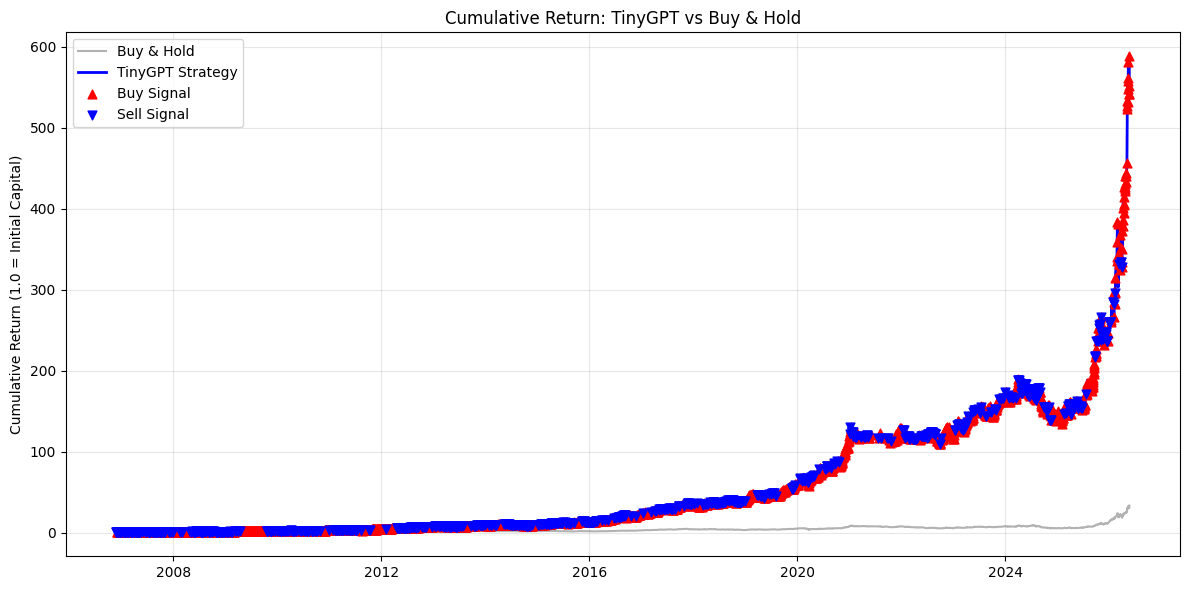

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 메모리에 있는 history_df 활용 및 전처리
# (만약 커널이 재시작되었다면 pd.read_csv('OUTPUT_HISTORY_경로')로 불러오시면 됩니다)
bt_df = history_df.dropna(subset=['pred_signal']).copy()
bt_df['date'] = pd.to_datetime(bt_df['date'])
bt_df = bt_df.sort_values('date').reset_index(drop=True)

# 2. 벤치마크 (단순 보유, Buy & Hold) 수익률 계산
bt_df['daily_return'] = bt_df['close'].pct_change()
bt_df['benchmark_cum_ret'] = (1 + bt_df['daily_return'].fillna(0)).cumprod()

# 3. 모델 시그널에 따른 포지션 설정 (벡터화 연산)
# 매수(BUY) = 주식 100% 보유 (1.0)
# 매도(SELL) = 전량 매도 후 현금 보유 (0.0)
# 관망(HOLD) = 이전 포지션 유지 (ffill)
bt_df['position'] = np.nan
bt_df.loc[bt_df['pred_signal'] == 'BUY', 'position'] = 1.0
bt_df.loc[bt_df['pred_signal'] == 'SELL', 'position'] = 0.0

# HOLD 구간은 이전 포지션을 그대로 가져오고, 맨 처음이 빈 값이면 0.0(현금)으로 채움
bt_df['position'] = bt_df['position'].ffill().fillna(0.0)

# 4. 미래 참조(Look-ahead bias) 방지 및 전략 수익률 계산
# 오늘 장 마감 후 시그널이 나왔다면, 내일의 수익률에 반영되어야 하므로 shift(1)을 적용합니다.
bt_df['strategy_return'] = bt_df['position'].shift(1) * bt_df['daily_return']
bt_df['strategy_cum_ret'] = (1 + bt_df['strategy_return'].fillna(0)).cumprod()

# 5. 성과 지표(MDD, CAGR) 계산 함수
def get_performance_metrics(cum_returns, dates):
    mdd = (cum_returns / cum_returns.cummax() - 1.0).min()
    total_return = cum_returns.iloc[-1] - 1
    days = (dates.iloc[-1] - dates.iloc[0]).days
    years = days / 365.25 if days > 0 else 1
    cagr = (1 + total_return) ** (1 / years) - 1
    return total_return, cagr, mdd

bm_ret, bm_cagr, bm_mdd = get_performance_metrics(bt_df['benchmark_cum_ret'], bt_df['date'])
st_ret, st_cagr, st_mdd = get_performance_metrics(bt_df['strategy_cum_ret'], bt_df['date'])

# 6. 결과 출력
print("=" * 45)
print(f"기간: {bt_df['date'].iloc[0].date()} ~ {bt_df['date'].iloc[-1].date()}")
print("-" * 45)
print(f"[단순 보유 (Buy & Hold)]")
print(f"누적 수익률: {bm_ret * 100:>7.2f}% | CAGR: {bm_cagr * 100:>6.2f}% | MDD: {bm_mdd * 100:>7.2f}%")
print("-" * 45)
print(f"[TinyGPT 전략]")
print(f"누적 수익률: {st_ret * 100:>7.2f}% | CAGR: {st_cagr * 100:>6.2f}% | MDD: {st_mdd * 100:>7.2f}%")
print("=" * 45)

# 7. 누적 수익률 그래프 시각화
plt.figure(figsize=(12, 6))
plt.plot(bt_df['date'], bt_df['benchmark_cum_ret'], label='Buy & Hold', color='gray', alpha=0.6)
plt.plot(bt_df['date'], bt_df['strategy_cum_ret'], label='TinyGPT Strategy', color='blue', linewidth=2)

# BUY/SELL 시점 표시 (선택 사항: 그래프가 너무 지저분해지면 아래 4줄은 주석 처리하세요)
buy_signals = bt_df[bt_df['pred_signal'] == 'BUY']
sell_signals = bt_df[bt_df['pred_signal'] == 'SELL']
plt.scatter(buy_signals['date'], buy_signals['strategy_cum_ret'], marker='^', color='red', s=40, label='Buy Signal', zorder=5)
plt.scatter(sell_signals['date'], sell_signals['strategy_cum_ret'], marker='v', color='blue', s=40, label='Sell Signal', zorder=5)

plt.title('Cumulative Return: TinyGPT vs Buy & Hold')
plt.ylabel('Cumulative Return (1.0 = Initial Capital)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

검증 기간 (Out-of-Sample): 2022-06-14 ~ 2026-05-21
적용 수수료/슬리피지: 매매당 0.25% 차감
-------------------------------------------------------
[단순 보유 (Buy & Hold)]
누적 수익률:  426.59% | CAGR:  52.54% | MDD:  -42.85%
-------------------------------------------------------
[TinyGPT 전략 (현실 반영)]
누적 수익률:  193.00% | CAGR:  31.42% | MDD:  -37.77%


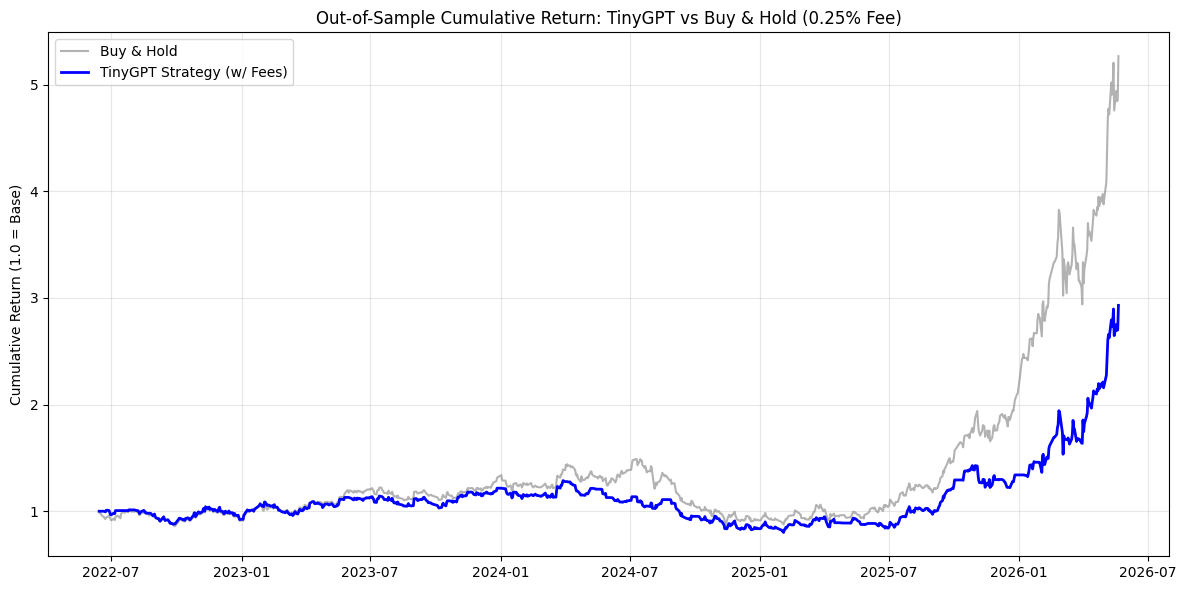

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 아웃오브샘플(Out-of-Sample) 구간 설정
# 전체 데이터의 80%는 학습에 사용되었으므로, 한 번도 보지 못한 최근 20%만 잘라냅니다.
bt_df = history_df.dropna(subset=['pred_signal']).copy()
bt_df['date'] = pd.to_datetime(bt_df['date'])
bt_df = bt_df.sort_values('date').reset_index(drop=True)

# 80% 지점 인덱스 계산
split_idx = int(len(bt_df) * 0.8)
bt_oos = bt_df.iloc[split_idx:].copy().reset_index(drop=True)

# 2. 벤치마크 (Buy & Hold) 수익률 재계산 (아웃오브샘플 기간 기준)
bt_oos['daily_return'] = bt_oos['close'].pct_change()
bt_oos['benchmark_cum_ret'] = (1 + bt_oos['daily_return'].fillna(0)).cumprod()

# 3. 모델 시그널에 따른 포지션 설정
bt_oos['position'] = np.nan
bt_oos.loc[bt_oos['pred_signal'] == 'BUY', 'position'] = 1.0
bt_oos.loc[bt_oos['pred_signal'] == 'SELL', 'position'] = 0.0
bt_oos['position'] = bt_oos['position'].ffill().fillna(0.0)

# 4. 현실적인 거래 비용(Transaction Cost) 적용
# 포지션이 변할 때마다(0->1 매수, 1->0 매도) 0.25%의 수수료 및 슬리피지가 발생한다고 가정합니다.
FEE_RATE = 0.0025
# diff().abs()를 쓰면 포지션이 변할 때 1이 되고, 유지될 땐 0이 됩니다.
bt_oos['trade_cost'] = bt_oos['position'].diff().abs().fillna(0.0) * FEE_RATE

# 5. 최종 전략 수익률 계산 (수익 - 거래비용)
# 내일의 수익률을 오늘 정한 포지션으로 곱한 뒤, 오늘 발생한 거래비용을 차감합니다.
bt_oos['strategy_return'] = bt_oos['position'].shift(1) * bt_oos['daily_return'] - bt_oos['trade_cost']
bt_oos['strategy_cum_ret'] = (1 + bt_oos['strategy_return'].fillna(0)).cumprod()

# 6. 성과 지표(MDD, CAGR) 계산 함수
def get_performance_metrics(cum_returns, dates):
    mdd = (cum_returns / cum_returns.cummax() - 1.0).min()
    total_return = cum_returns.iloc[-1] - 1
    days = (dates.iloc[-1] - dates.iloc[0]).days
    years = days / 365.25 if days > 0 else 1
    cagr = (1 + total_return) ** (1 / years) - 1
    return total_return, cagr, mdd

bm_ret, bm_cagr, bm_mdd = get_performance_metrics(bt_oos['benchmark_cum_ret'], bt_oos['date'])
st_ret, st_cagr, st_mdd = get_performance_metrics(bt_oos['strategy_cum_ret'], bt_oos['date'])

# 7. 결과 출력
print("=" * 55)
print(f"검증 기간 (Out-of-Sample): {bt_oos['date'].iloc[0].date()} ~ {bt_oos['date'].iloc[-1].date()}")
print(f"적용 수수료/슬리피지: 매매당 {FEE_RATE * 100}% 차감")
print("-" * 55)
print(f"[단순 보유 (Buy & Hold)]")
print(f"누적 수익률: {bm_ret * 100:>7.2f}% | CAGR: {bm_cagr * 100:>6.2f}% | MDD: {bm_mdd * 100:>7.2f}%")
print("-" * 55)
print(f"[TinyGPT 전략 (현실 반영)]")
print(f"누적 수익률: {st_ret * 100:>7.2f}% | CAGR: {st_cagr * 100:>6.2f}% | MDD: {st_mdd * 100:>7.2f}%")
print("=" * 55)

# 8. 시각화
plt.figure(figsize=(12, 6))
plt.plot(bt_oos['date'], bt_oos['benchmark_cum_ret'], label='Buy & Hold', color='gray', alpha=0.6)
plt.plot(bt_oos['date'], bt_oos['strategy_cum_ret'], label='TinyGPT Strategy (w/ Fees)', color='blue', linewidth=2)

plt.title('Out-of-Sample Cumulative Return: TinyGPT vs Buy & Hold (0.25% Fee)')
plt.ylabel('Cumulative Return (1.0 = Base)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. 운영 스크립트 사용 예시

노트북은 설명용이며, 실제 트레이더 루프에서는 다음처럼 스크립트를 실행하는 것이 단순합니다.

```bash
# 1) 먼저 export_history.py로 CSV를 최신화합니다.
PYTHONPATH=./samsung_auto_trader python samsung_auto_trader/export_history.py \
  --symbol 005930 \
  --output Samsung_Daily_Data_yfinance.csv \
  --period D \
  --adj 1 \
  --market J

# 2) 갱신된 CSV로 Tiny GPT trading signal을 생성합니다.
python tiny_GPT_trading_signal.py \
  --csv Samsung_Daily_Data_yfinance.csv \
  --output-json latest_trading_signal.json \
  --output-history trading_signals_history.csv
```

트레이더는 `latest_trading_signal.json`의 `prediction.trading_signal` 값을 읽어 `BUY`, `HOLD`, `SELL` 중 하나로 행동하면 됩니다. 기존 README의 단순 `current_price - 2000` 매수, `current_price + 2000` 매도 규칙은 이 신호 기반 로직으로 교체됩니다.[^execution_logic]

[^execution_logic]: 예를 들어 `BUY`이면 보유 수량과 현금 한도를 확인한 뒤 지정가 또는 시장가 매수를 검토하고, `SELL`이면 보유 수량이 있을 때 매도를 검토합니다. `HOLD`이면 신규 주문을 내지 않는 방식이 가장 보수적입니다.